# Tomato Leaf Disease Classification

<img src="https://storage.googleapis.com/kaggle-datasets-images/8201386/12958946/a163d49a7e1451cc12a14dc843f4e65b/dataset-cover.jpg?t=2025-09-04-10-32-49">

## 1. Import Libraries

In [ ]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

## 2. Download Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("naveedgull/tomato-leaf-disease")

print("Path to dataset files:", path)

100%|██████████| 284M/284M [00:13<00:00, 21.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/naveedgull/tomato-leaf-disease/versions/1


In [ ]:
os.listdir("/root/.cache/kagglehub/datasets/naveedgull/tomato-leaf-disease/versions/1/Tomato Leaf Disease/train")

['Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Early_blight',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Late_blight',
 'Tomato___Bacterial_spot',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy',
 'Tomato___Target_Spot',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Leaf_Mold']

## 3. Configurations

In [ ]:
# Dataset config
# DATASET_PATH = "/kaggle/input/datasets/naveedgull/tomato-leaf-disease/Tomato Leaf Disease"
DATASET_PATH = "/root/.cache/kagglehub/datasets/naveedgull/tomato-leaf-disease/versions/1/Tomato Leaf Disease"
TRAIN_PATH = os.path.join(DATASET_PATH, "train")
SPLIT_BASE = "/tmp/tomato_split"
SPLIT_TRAIN = os.path.join(SPLIT_BASE, "train")
SPLIT_VAL = os.path.join(SPLIT_BASE, "val")
SPLIT_TEST = os.path.join(SPLIT_BASE, "test")

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 5
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_SEED = 42

# Map from raw folder name to clean label
CLASS_MAP = {
    "Tomato___healthy": "Healthy",
    "Tomato___Septoria_leaf_spot": "Septoria",
    "Tomato___Target_Spot": "Target Spot",
    "Tomato___Bacterial_spot": "Bacterial Spot"
}
RAW_CLASSES = list(CLASS_MAP.keys())
CLASS_NAMES = list(CLASS_MAP.values())
NUM_CLASSES = len(CLASS_NAMES)

## 4. Split Data into Training and Test Sets

In [ ]:
# Build train / val / test splits from the original train folder
random.seed(RANDOM_SEED)

if os.path.exists(SPLIT_BASE):
    shutil.rmtree(SPLIT_BASE)

for raw_cls, clean_name in CLASS_MAP.items():
    src_folder = os.path.join(TRAIN_PATH, raw_cls)
    all_images = [f for f in os.listdir(src_folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    random.shuffle(all_images)

    n = len(all_images)
    n_train = int(n * TRAIN_RATIO)
    n_val = int(n * VAL_RATIO)

    train_imgs = all_images[:n_train]
    val_imgs = all_images[n_train:n_train + n_val]
    test_imgs = all_images[n_train + n_val:]

    for split, imgs in [("train", train_imgs), ("val", val_imgs), ("test", test_imgs)]:
        dest = os.path.join(SPLIT_BASE, split, clean_name)
        os.makedirs(dest, exist_ok=True)
        for img in imgs:
            shutil.copy(os.path.join(src_folder, img), os.path.join(dest, img))

print("Split complete.")
for split in ["train", "val", "test"]:
    for cls in CLASS_NAMES:
        count = len(os.listdir(os.path.join(SPLIT_BASE, split, cls)))
        print(f"  {split}/{cls}: {count} images")

Split complete.
  train/Healthy: 890 images
  train/Septoria: 991 images
  train/Target Spot: 786 images
  train/Bacterial Spot: 1190 images
  val/Healthy: 190 images
  val/Septoria: 212 images
  val/Target Spot: 168 images
  val/Bacterial Spot: 255 images
  test/Healthy: 192 images
  test/Septoria: 213 images
  test/Target Spot: 169 images
  test/Bacterial Spot: 256 images


## 5. Sample Data Visualisation

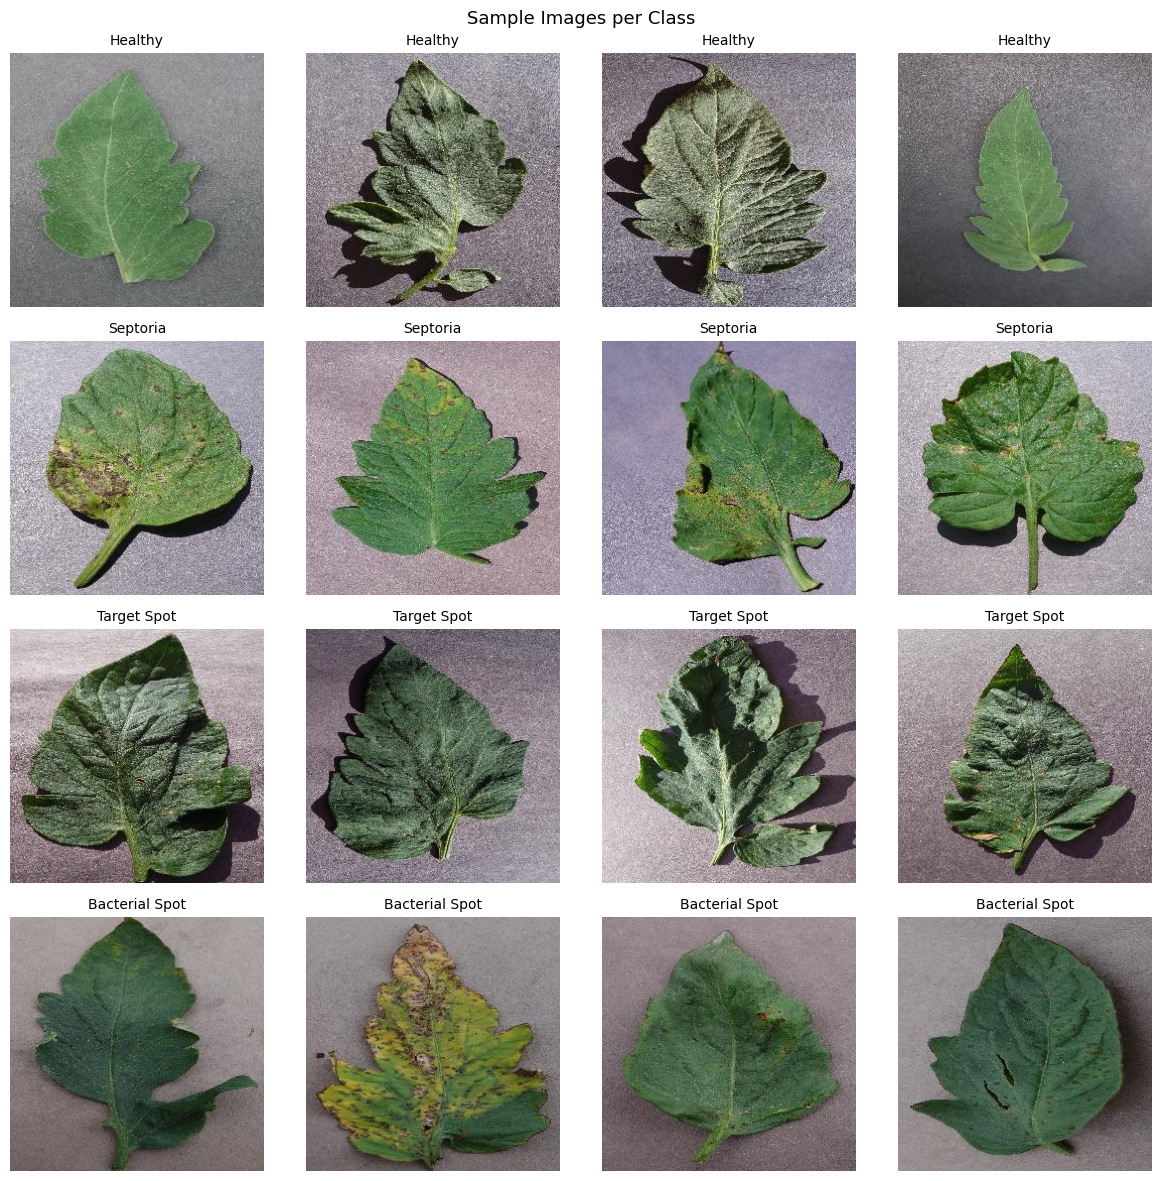

In [ ]:
# Each class occupies one row, 4 images per row, label on every image

SAMPLES_PER_CLASS = 4
fig, axes = plt.subplots(NUM_CLASSES, SAMPLES_PER_CLASS, figsize=(SAMPLES_PER_CLASS * 3, NUM_CLASSES * 3))

for row, cls_name in enumerate(CLASS_NAMES):
    cls_folder = os.path.join(SPLIT_TRAIN, cls_name)
    images = [f for f in os.listdir(cls_folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))][:SAMPLES_PER_CLASS]

    for col, img_name in enumerate(images):
        img_path = os.path.join(cls_folder, img_name)
        img = plt.imread(img_path)
        axes[row][col].imshow(img)
        axes[row][col].axis("off")
        # Label on every image
        axes[row][col].set_title(cls_name, fontsize=10)

plt.suptitle("Sample Images per Class", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Sample Data Augmentation

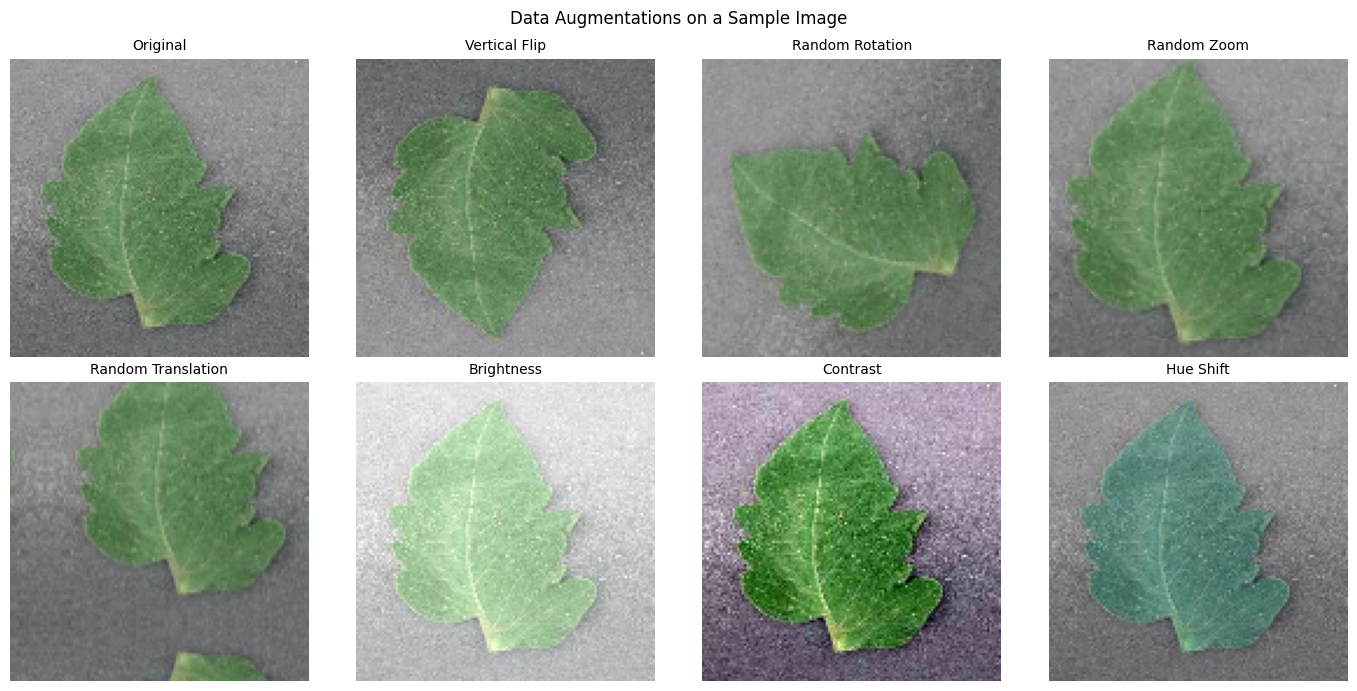

In [ ]:
sample_img_folder = os.path.join(SPLIT_TRAIN, CLASS_NAMES[0])
sample_img_file = os.listdir(sample_img_folder)[0]
sample_img_path = os.path.join(sample_img_folder, sample_img_file)

img = tf.keras.utils.load_img(sample_img_path, target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(img) / 255.0
img_expanded = np.expand_dims(img_array, axis=0)

augmentations = {
    "Original": img_array,
    "Vertical Flip": tf.image.flip_up_down(img_array).numpy(),
    "Random Rotation": tf.keras.layers.RandomRotation(0.3)(img_expanded, training=True)[0].numpy().clip(0, 1),
    "Random Zoom": tf.keras.layers.RandomZoom(0.3)(img_expanded, training=True)[0].numpy().clip(0, 1),
    "Random Translation": tf.keras.layers.RandomTranslation(0.2, 0.2)(img_expanded, training=True)[0].numpy().clip(0, 1),
    "Brightness": tf.image.adjust_brightness(img_array, 0.3).numpy().clip(0, 1),
    "Contrast": tf.image.adjust_contrast(img_array, 2).numpy().clip(0, 1),
    "Hue Shift": tf.image.adjust_hue(img_array, 0.15).numpy().clip(0, 1),
}

aug_titles = list(augmentations.keys())
aug_images = list(augmentations.values())

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, (title, aug_img) in enumerate(augmentations.items()):
    axes[i].imshow(aug_img)
    axes[i].set_title(title, fontsize=10)
    axes[i].axis("off")

plt.suptitle("Data Augmentations on a Sample Image", fontsize=12)
plt.tight_layout()
plt.show()

## 7. Data Generators

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_gen = train_datagen.flow_from_directory(
    SPLIT_TRAIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=RANDOM_SEED
)

Found 3857 images belonging to 4 classes.


In [ ]:
val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

val_gen = val_test_datagen.flow_from_directory(
    SPLIT_VAL,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 825 images belonging to 4 classes.


In [ ]:
test_gen = val_test_datagen.flow_from_directory(
    SPLIT_TEST,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 830 images belonging to 4 classes.


In [ ]:
# Class order as assigned by the generator
gen_class_names = [k for k, v in sorted(train_gen.class_indices.items(), key=lambda x: x[1])]
print("Generator class order:", gen_class_names)

Generator class order: ['Bacterial Spot', 'Healthy', 'Septoria', 'Target Spot']


## 8. Convolutional Neural Network (CNN) Model

In [ ]:
def build_cnn(num_classes, img_size):
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(*img_size, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

cnn_model = build_cnn(NUM_CLASSES, IMG_SIZE)

In [ ]:
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,156 (1.74 MB)

 Trainable params: 456,196 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
cnn_callbacks = [
    keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)
]

cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=cnn_callbacks
)

Epoch 1/5
121/121 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.8813 - loss: 0.3296 - val_accuracy: 0.3091 - val_loss: 4.8409 - learning_rate: 0.0010
Epoch 2/5
121/121 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.9186 - loss: 0.2214 - val_accuracy: 0.3103 - val_loss: 8.0166 - learning_rate: 0.0010
Epoch 3/5
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9359 - loss: 0.1660
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
121/121 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.9370 - loss: 0.1653 - val_accuracy: 0.4848 - val_loss: 5.9245 - learning_rate: 0.0010
Epoch 4/5
121/121 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.9567 - loss: 0.1202 - val_accuracy: 0.7079 - val_loss: 1.3381 - learning_rate: 5.0000e-04
Epoch 5/5
121/121 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.9642 - loss: 0.1043 - val_accuracy: 0.8958 - val_loss: 0.3928 - learning_rate: 5.0000e-04


In [ ]:
def evaluate_model(model, test_gen, class_names, model_name):
    test_gen.reset()
    y_pred_probs = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_gen.classes

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n{model_name} Test Set Metrics")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{model_name} Confusion Matrix (Test Set)")
    plt.xticks(fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

    # Return true and predicted labels for use outside the function
    return y_true, y_pred

26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 308ms/step

Custom CNN Test Set Metrics
Accuracy:  0.9060
Precision: 0.9134
Recall:    0.9060
F1 Score:  0.9043


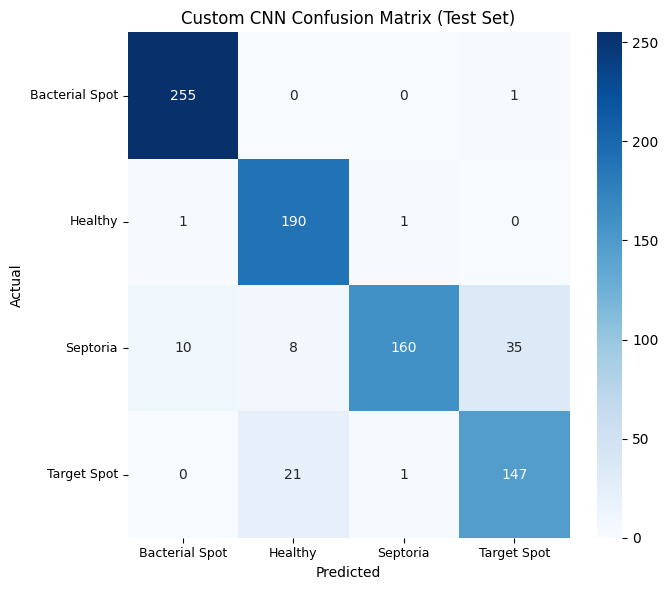

In [ ]:
cnn_true, cnn_pred = evaluate_model(cnn_model, test_gen, gen_class_names, "Custom CNN")

## 9. Transfer Learning: Resnet50

Diminishing Gradient

Vanishing Gradient Problem

0.05 x 0.1 x 0.1 =
....0.0000000000000000000005 ~ 0

Chain RULE -> derivate A (gradient) x derivate B (gradient) = Even smaller gradient

When you multiply two small decimals, you get an even smaller decimal!!!

<img src="https://aiml.com/wp-content/uploads/2023/09/Vanishing-Gradients_neptune-ai.webp">

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRO-2FPPZWrA44RvHGkb8y521eKlX05fKVfJ5dfm7tVRg&s=10">

<img src="https://www.researchgate.net/profile/Master-Prince/publication/350421671/figure/fig1/AS:1005790324346881@1616810508674/An-illustration-of-ResNet-50-layers-architecture.png">

In [ ]:
# ResNet50 generator: no rescale, use resnet's own preprocessing as a lambda layer
resnet_train_datagen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess,  # replaces rescale=1/255
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

resnet_val_test_datagen = ImageDataGenerator(preprocessing_function=resnet_preprocess)

In [ ]:
# Recreate all generators with the correct preprocessing and larger image size
TARGET_SIZE = (224, 224)  # native ImageNet resolution, much better for transfer learning

resnet_train_gen = resnet_train_datagen.flow_from_directory(
    SPLIT_TRAIN, target_size=TARGET_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=True, seed=RANDOM_SEED
)

resnet_val_gen = resnet_val_test_datagen.flow_from_directory(
    SPLIT_VAL, target_size=TARGET_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

resnet_test_gen = resnet_val_test_datagen.flow_from_directory(
    SPLIT_TEST, target_size=TARGET_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

Found 3857 images belonging to 4 classes.
Found 825 images belonging to 4 classes.
Found 830 images belonging to 4 classes.


In [ ]:
def build_resnet50(num_classes, img_size):
    # Load pretrained ResNet50 without the top classification layer
    base = ResNet50(weights="imagenet", include_top=False, input_shape=(*img_size, 3))

    # Freeze the base model weights initially, we only train the new head
    base.trainable = False

    model = keras.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

resnet_model = build_resnet50(NUM_CLASSES, IMG_SIZE)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
resnet_model = build_resnet50(NUM_CLASSES, TARGET_SIZE)
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
resnet_callbacks = [
    keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)
]

resnet_model.fit(
    resnet_train_gen,
    validation_data=resnet_val_gen,
    epochs=EPOCHS,
    callbacks=resnet_callbacks
)

Epoch 1/5
121/121 ━━━━━━━━━━━━━━━━━━━━ 556s 5s/step - accuracy: 0.8242 - loss: 0.4792 - val_accuracy: 0.8861 - val_loss: 0.2541 - learning_rate: 0.0010
Epoch 2/5
121/121 ━━━━━━━━━━━━━━━━━━━━ 610s 5s/step - accuracy: 0.9157 - loss: 0.2119 - val_accuracy: 0.9576 - val_loss: 0.1273 - learning_rate: 0.0010
Epoch 3/5
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9372 - loss: 0.1686

In [ ]:
resnet_true, resnet_pred = evaluate_model(resnet_model, resnet_test_gen, gen_class_names, "ResNet50")

## 10. Transfer Learning: VGG16

<img src="https://www.researchgate.net/publication/355049790/figure/fig2/AS:1075420338348033@1633411597542/The-structure-of-VGG16-modelThis-figure-was-created-with-Image-onlineco-and-exported.png">

In [ ]:
# VGG16 generator: same idea, different preprocess function
vgg_train_datagen = ImageDataGenerator(
    preprocessing_function=vgg_preprocess,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

vgg_val_test_datagen = ImageDataGenerator(preprocessing_function=vgg_preprocess)

In [ ]:
vgg_train_gen = vgg_train_datagen.flow_from_directory(
    SPLIT_TRAIN, target_size=TARGET_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=True, seed=RANDOM_SEED
)

vgg_val_gen = vgg_val_test_datagen.flow_from_directory(
    SPLIT_VAL, target_size=TARGET_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

vgg_test_gen = vgg_val_test_datagen.flow_from_directory(
    SPLIT_TEST, target_size=TARGET_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

In [ ]:
def build_vgg16(num_classes, img_size):
    # Load pretrained VGG16 without the top classification layers
    base = VGG16(weights="imagenet", include_top=False, input_shape=(*img_size, 3))

    # Freeze base model so only the new head is trained
    base.trainable = False

    model = keras.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

In [ ]:
vgg_model = build_vgg16(NUM_CLASSES, TARGET_SIZE)
vgg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
vgg_callbacks = [
    keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)
]

vgg_model.fit(
    vgg_train_gen,
    validation_data=vgg_val_gen,
    epochs=EPOCHS,
    callbacks=vgg_callbacks
)

In [ ]:
vgg_true, vgg_pred = evaluate_model(vgg_model, vgg_test_gen, gen_class_names, "VGG16")

## 11. Sample Evaluation Grid

In [ ]:
def plot_prediction_grid(model, test_gen, model_name, samples_per_class=4):
    """
    Plots a 4x4 grid of sample images with predicted and actual labels.
    Samples evenly across all classes to avoid the one-class-dominance problem
    that occurs when you grab a single batch from an unshuffled generator.
    """

    test_gen.reset()

    # Collect all images and labels by running through the full generator
    all_images = []
    all_true_indices = []

    for batch_imgs, batch_labels in test_gen:
        all_images.append(batch_imgs)
        all_true_indices.append(np.argmax(batch_labels, axis=1))
        # Stop once we have looped through the full dataset
        if len(all_images) >= len(test_gen):
            break

    all_images = np.concatenate(all_images, axis=0)
    all_true_indices = np.concatenate(all_true_indices, axis=0)

    # Run predictions on everything at once
    all_preds = model.predict(all_images, verbose=0)
    all_pred_indices = np.argmax(all_preds, axis=1)

    idx_to_class = {v: k for k, v in test_gen.class_indices.items()}
    num_classes = len(idx_to_class)

    # Pick samples_per_class random images from each class
    selected_images = []
    selected_true = []
    selected_pred = []

    for class_idx in range(num_classes):
        # Find all positions in the dataset belonging to this class
        class_positions = np.where(all_true_indices == class_idx)[0]
        chosen = np.random.choice(class_positions, size=samples_per_class, replace=False)

        selected_images.append(all_images[chosen])
        selected_true.append(all_true_indices[chosen])
        selected_pred.append(all_pred_indices[chosen])

    selected_images = np.concatenate(selected_images, axis=0)
    selected_true = np.concatenate(selected_true, axis=0)
    selected_pred = np.concatenate(selected_pred, axis=0)

    # Plot the 4x4 grid
    fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(14, 14))
    axes = axes.flatten()

    for i in range(num_classes * samples_per_class):
        img = selected_images[i]
        true_label = idx_to_class[selected_true[i]]
        pred_label = idx_to_class[selected_pred[i]]
        correct = true_label == pred_label

        # Normalise display range back to [0, 1] since preprocessing shifts pixel values
        img_display = img - img.min()
        img_display = img_display / img_display.max()

        axes[i].imshow(img_display)
        axes[i].axis("off")
        axes[i].set_title(
            f"Actual: {true_label}\nPred: {pred_label}",
            fontsize=9,
            color="green" if correct else "red"
        )

    plt.suptitle(
        f"{model_name}: Predicted vs Actual (green = correct, red = wrong)\n"
        f"{samples_per_class} samples per class",
        fontsize=12, y=1.01
    )
    plt.tight_layout()
    plt.show()

In [ ]:
plot_prediction_grid(resnet_model, resnet_test_gen, "ResNet50")

In [ ]:
# Swap in any other model the same way
# plot_prediction_grid(vgg_model, vgg_test_gen, "VGG16")
# plot_prediction_grid(cnn_model, test_gen, "Custom CNN")